In [ ]:
import math
import pandas as pd
from datetime import datetime, timedelta
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# solarsystem
import solarsystem
print('Solarsystem version:',solarsystem.__version__)
from solarsystem.functions import demical2arcs

# skyfield
from skyfield.api import load

Solarsystem version: 0.1.8


In [ ]:
# ------------------------------------------------------------
# SINGLE DAY TEST CONFIGURATION
# ------------------------------------------------------------

YEAR = 2025
MONTH = 1
DAY = 1
HOUR = 12
MINUTE = 0

PLANETS = [
    "Mercury",
    "Venus",
    "Earth",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune",
    "Pluto"
]

In [ ]:
# ------------------------------------------------------------
# SOLARSYSTEM POSITIONS
# ------------------------------------------------------------

H = solarsystem.Heliocentric(
    year=YEAR,
    month=MONTH,
    day=DAY,
    hour=HOUR,
    minute=MINUTE
)

ss_positions = H.planets()

# ------------------------------------------------------------
# SKYFIELD POSITIONS
# ------------------------------------------------------------

ts = load.timescale()
t = ts.utc(YEAR, MONTH, DAY, HOUR, MINUTE)

# JPL DE440 ephemeris will be used for the comparison
eph = load('de440.bsp')
# eph = load('de421.bsp')

sun = eph['sun']

planet_map = {
    "Mercury": eph['mercury barycenter'],
    "Venus": eph['venus barycenter'],
    "Earth": eph['earth barycenter'],
    "Mars": eph['mars barycenter'],
    "Jupiter": eph['jupiter barycenter'],
    "Saturn": eph['saturn barycenter'],
    "Uranus": eph['uranus barycenter'],
    "Neptune": eph['neptune barycenter'],
    "Pluto": eph['pluto barycenter']
}


In [ ]:
# ------------------------------------------------------------
# COMPARISON - SINGLE DATE
# ------------------------------------------------------------

results = []

for planet in PLANETS:

    # -------------------------
    # solarsystem values
    # -------------------------

    ss_lon = ss_positions[planet][0]
    ss_lat = ss_positions[planet][1]
    ss_r   = ss_positions[planet][2]

    # -------------------------
    # skyfield values
    # -------------------------

    astrometric = sun.at(t).observe(planet_map[planet])

    lat, lon, distance = astrometric.ecliptic_latlon()

    sf_lon = lon.degrees % 360
    sf_lat = lat.degrees
    sf_r   = distance.au

    # -------------------------
    # errors
    # -------------------------

    lon_error = abs(ss_lon - sf_lon)

    # handle wrap-around
    if lon_error > 180:
        lon_error = 360 - lon_error


    lat_error = abs(ss_lat - sf_lat)

    dist_error = abs(ss_r - sf_r)

    results.append({
        "Planet": planet,
        "SS Longitude": round(ss_lon, 4),
        "SF Longitude": round(sf_lon, 4),
        "Longitude Error (deg)": round(lon_error, 6),

        "SS Latitude": round(ss_lat, 4),
        "SF Latitude": round(sf_lat, 4),
        "Latitude Error (deg)": round(lat_error, 6),

        "SS Distance (AU)": round(ss_r, 6),
        "SF Distance (AU)": round(sf_r, 6),
        "Distance Error (AU)": round(dist_error, 8),
        "Distance Error (%)": round(100*dist_error/(0.5*ss_r+0.5*sf_r), 8)
    })

In [ ]:
print(results)

[{'Planet': 'Mercury', 'SS Longitude': 204.3446, 'SF Longitude': np.float64(204.3391), 'Longitude Error (deg)': np.float64(0.005458), 'SS Latitude': 2.8538, 'SF Latitude': np.float64(2.8561), 'Latitude Error (deg)': np.float64(0.002323), 'SS Distance (AU)': 0.422659, 'SF Distance (AU)': np.float64(0.422652), 'Distance Error (AU)': np.float64(7.43e-06), 'Distance Error (%)': np.float64(0.00175802)}, {'Planet': 'Venus', 'SS Longitude': 51.9114, 'SF Longitude': np.float64(51.911), 'Longitude Error (deg)': np.float64(0.000387), 'SS Latitude': -1.417, 'SF Latitude': np.float64(-1.4198), 'Latitude Error (deg)': np.float64(0.002848), 'SS Distance (AU)': 0.722424, 'SF Distance (AU)': np.float64(0.72244), 'Distance Error (AU)': np.float64(1.606e-05), 'Distance Error (%)': np.float64(0.00222309)}, {'Planet': 'Earth', 'SS Longitude': 100.9809, 'SF Longitude': np.float64(100.9735), 'Longitude Error (deg)': np.float64(0.007407), 'SS Latitude': 0.0, 'SF Latitude': np.float64(-0.0031), 'Latitude Erro

In [ ]:
# ------------------------------------------------------------
# OUTPUT TABLE
# ------------------------------------------------------------

df = pd.DataFrame(results)

print("\nValidation Against Skyfield / JPL DE440\n")
print(df.to_string(index=False))


Validation Against Skyfield / JPL DE440

 Planet  SS Longitude  SF Longitude  Longitude Error (deg)  SS Latitude  SF Latitude  Latitude Error (deg)  SS Distance (AU)  SF Distance (AU)  Distance Error (AU)  Distance Error (%)
Mercury      204.3446      204.3391               0.005458       2.8538       2.8561              0.002323          0.422659          0.422652             0.000007            0.001758
  Venus       51.9114       51.9110               0.000387      -1.4170      -1.4198              0.002848          0.722424          0.722440             0.000016            0.002223
  Earth      100.9809      100.9735               0.007407       0.0000      -0.0031              0.003114          0.983312          0.983318             0.000006            0.000597
   Mars      109.1217      109.1115               0.010230       1.5974       1.5941              0.003252          1.613103          1.613078             0.000025            0.001563
Jupiter       78.0597       78.0485   

In [ ]:
df[['Longitude Error (deg)', 'Latitude Error (deg)', 'Distance Error (AU)']].values

array([[5.458000e-03, 2.323000e-03, 7.430000e-06],
       [3.870000e-04, 2.848000e-03, 1.606000e-05],
       [7.407000e-03, 3.114000e-03, 5.870000e-06],
       [1.023000e-02, 3.252000e-03, 2.522000e-05],
       [1.124200e-02, 4.146000e-03, 1.851790e-03],
       [8.785000e-03, 1.800000e-04, 2.276466e-02],
       [2.151700e-02, 3.105000e-03, 1.919512e-02],
       [2.216000e-03, 2.210000e-04, 1.793509e-02],
       [5.617000e-03, 1.808000e-03, 5.408849e-02]])

In [ ]:
# ------------------------------------------------------------
# OPTIONAL: SAVE CSV
# ------------------------------------------------------------

df.to_csv("solarsystem_validation.csv", index=False)

print("\nSaved results to solarsystem_validation.csv")


Saved results to solarsystem_validation.csv


In [ ]:
YEAR

2025

In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER DAY (at 12 noon) FOR A SINGLE YEAR
# ------------------------------------------------------------

# d = datetime.datetime()
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)

res=[]

for nd in tqdm(range(365)):
    f = d + timedelta(days=nd)

    # ------------------------------------------------------------
    # SOLARSYSTEM POSITIONS
    # ------------------------------------------------------------

    H = solarsystem.Heliocentric(
    year=f.year,
    month=f.month,
    day=f.day,
    hour=HOUR,
    minute=MINUTE
)

    ss_positions = H.planets()

    # ------------------------------------------------------------
    # Time for skyfield
    # ------------------------------------------------------------

    ts = load.timescale()
    t = ts.utc(f.year, f.month, f.day, HOUR, MINUTE)

    results = []

    for planet in PLANETS:

        # -------------------------
        # solarsystem values
        # -------------------------

        ss_lon = ss_positions[planet][0]
        ss_lat = ss_positions[planet][1]
        ss_r   = ss_positions[planet][2]

        # -------------------------
        # skyfield values
        # -------------------------

        astrometric = sun.at(t).observe(planet_map[planet])

        lat, lon, distance = astrometric.ecliptic_latlon()

        sf_lon = lon.degrees % 360
        sf_lat = lat.degrees
        sf_r   = distance.au

        # -------------------------
        # errors
        # -------------------------

        lon_error = abs(ss_lon - sf_lon)

        # handle wrap-around
        if lon_error > 180:
            lon_error = 360 - lon_error


        lat_error = abs(ss_lat - sf_lat)

        dist_error = abs(ss_r - sf_r)

        results.append({
            "Planet": planet,
            "SS Longitude": round(ss_lon, 4),
            "SF Longitude": round(sf_lon, 4),
            "Longitude Error (deg)": round(lon_error, 6),

            "SS Latitude": round(ss_lat, 4),
            "SF Latitude": round(sf_lat, 4),
            "Latitude Error (deg)": round(lat_error, 6),

            "SS Distance (AU)": round(ss_r, 6),
            "SF Distance (AU)": round(sf_r, 6),
            "Distance Error (AU)": round(dist_error, 8),
            "Distance Error (%)": round(100*dist_error/(0.5*ss_r+0.5*sf_r), 8)
        })
    df = pd.DataFrame(results)

    res.append(df[['Longitude Error (deg)', 'Latitude Error (deg)', 'Distance Error (%)']].values)

100%|██████████| 365/365 [00:11<00:00, 30.74it/s]


In [ ]:
np.stack(res).shape,np.stack(res).mean((0,1)),np.abs(np.stack(res)).mean((0,1))

((365, 9, 3),
 array([0.00808076, 0.00211275, 0.06425205]),
 array([0.00808076, 0.00211275, 0.06425205]))

In [ ]:
demical2arcs(np.abs(np.stack(res)).mean((0,1))[0]),demical2arcs(np.abs(np.stack(res)).mean((0,1))[1])

("0° 0.48'", "0° 0.13'")

In [ ]:
print('PLANET  \t','LONG DIFF \t', 'LAT DIFF \t', 'DISTANCE DIFF')
absres=np.round(np.abs(np.stack(res)).mean((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', absres[en,0], '\t', absres[en,1], '\t', absres[en,2])


PLANET  	 LONG DIFF 	 LAT DIFF 	 DISTANCE DIFF
Mercury    	 0.005114 	 0.00243 	 0.001567
Venus    	 0.004597 	 0.002355 	 0.001633
Earth    	 0.006899 	 0.002158 	 0.002306
Mars    	 0.009526 	 0.002226 	 0.004333
Jupiter    	 0.009117 	 0.004084 	 0.031562
Saturn    	 0.009818 	 0.000509 	 0.238583
Uranus    	 0.021544 	 0.0032 	 0.09695
Neptune    	 0.002796 	 0.000301 	 0.0558
Pluto    	 0.003315 	 0.001751 	 0.145536


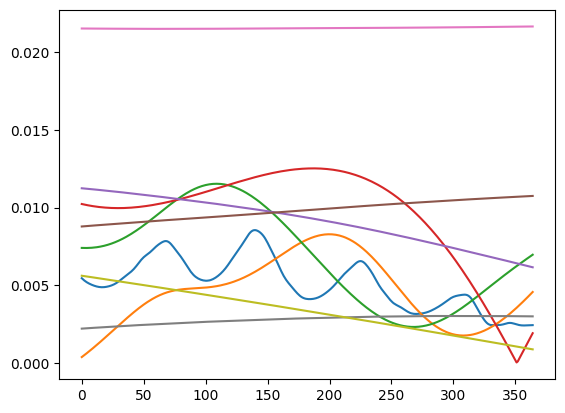

In [ ]:
for i in range(9):
    plt.plot(np.stack(res)[:,i,0])
plt.show()

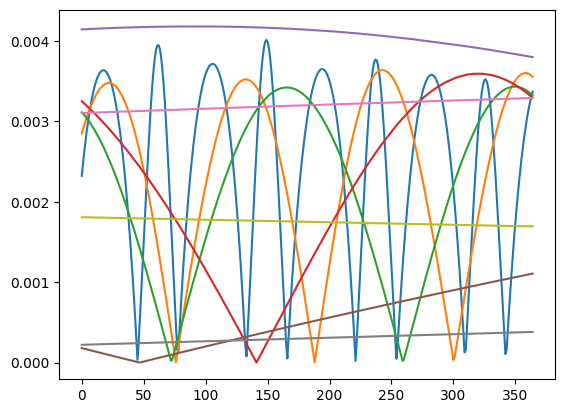

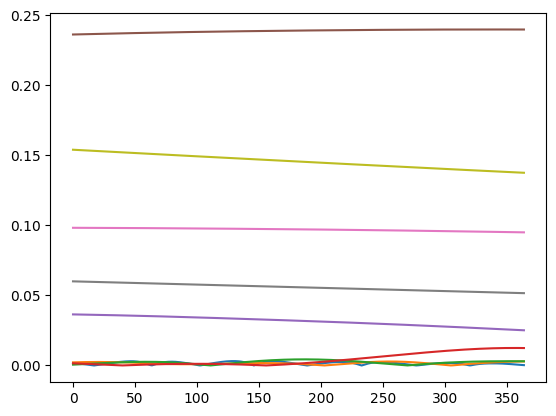

In [ ]:
for i in range(9):
    plt.plot(np.stack(res)[:,i,1])
plt.show()
for i in range(9):
    plt.plot(np.stack(res)[:,i,2])
plt.show()

In [ ]:
MONTH, DAY

(1, 1)

In [ ]:
# ------------------------------------------------------------
# COMPARISON - FROM 50 YEARS BEFORE 2000 UP TO 50 YEARS AFTER
# ------------------------------------------------------------

# d = datetime.datetime()
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)

res=[]

for YEAR in tqdm(range(1950,2051)):

    # ------------------------------------------------------------
    # SOLARSYSTEM POSITIONS
    # ------------------------------------------------------------

    H = solarsystem.Heliocentric(
    year=YEAR,
    month=MONTH,
    day=DAY,
    hour=HOUR,
    minute=MINUTE,
    precession=True
)

    ss_positions = H.planets()

    # ------------------------------------------------------------
    # Time for skyfield
    # ------------------------------------------------------------

    ts = load.timescale()
    t = ts.utc(YEAR, MONTH, DAY, HOUR, MINUTE)

    results = []

    for planet in PLANETS:

        # -------------------------
        # solarsystem values
        # -------------------------

        ss_lon = ss_positions[planet][0]
        ss_lat = ss_positions[planet][1]
        ss_r   = ss_positions[planet][2]


        # -------------------------
        # skyfield values
        # -------------------------

        astrometric = sun.at(t).observe(planet_map[planet])

        lat, lon, distance = astrometric.ecliptic_latlon()

        sf_lon = lon.degrees % 360
        sf_lat = lat.degrees
        sf_r   = distance.au

        # -------------------------
        # errors
        # -------------------------

        lon_error = abs(ss_lon - sf_lon)

        # handle wrap-around
        if lon_error > 180:
            lon_error = 360 - lon_error


        lat_error = abs(ss_lat - sf_lat)

        dist_error = abs(ss_r - sf_r)

        results.append({
            "Planet": planet,
            "SS Longitude": round(ss_lon, 4),
            "SF Longitude": round(sf_lon, 4),
            "Longitude Error (deg)": round(lon_error, 6),

            "SS Latitude": round(ss_lat, 4),
            "SF Latitude": round(sf_lat, 4),
            "Latitude Error (deg)": round(lat_error, 6),

            "SS Distance (AU)": round(ss_r, 6),
            "SF Distance (AU)": round(sf_r, 6),
            "Distance Error (AU)": round(dist_error, 8),
            "Distance Error (%)": round(100*dist_error/(0.5*ss_r+0.5*sf_r), 8)
        })
    df = pd.DataFrame(results)

    res.append(df[['Longitude Error (deg)', 'Latitude Error (deg)', 'Distance Error (%)']].values)

100%|██████████| 101/101 [00:01<00:00, 71.07it/s]


In [ ]:
np.stack(res).shape,np.stack(res).mean((0,1)),np.abs(np.stack(res)).mean((0,1))

((101, 9, 3),
 array([0.00736716, 0.00269976, 0.05035441]),
 array([0.00736716, 0.00269976, 0.05035441]))

In [ ]:
demical2arcs(np.abs(np.stack(res)).mean((0,1))[0]),demical2arcs(np.abs(np.stack(res)).mean((0,1))[1])

("0° 0.44'", "0° 0.16'")

In [ ]:
print('MEAN')
print('PLANET  \t','LONG DIFF \t', 'LAT DIFF \t', 'DISTANCE DIFF')
absres=np.round(np.abs(np.stack(res)).mean((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', absres[en,0], '\t', absres[en,1], '\t', absres[en,2])


MEAN
PLANET  	 LONG DIFF 	 LAT DIFF 	 DISTANCE DIFF
Mercury    	 0.005371 	 0.002181 	 0.00153
Venus    	 0.005085 	 0.002099 	 0.001981
Earth    	 0.006672 	 0.003175 	 0.001456
Mars    	 0.007843 	 0.001978 	 0.005313
Jupiter    	 0.006149 	 0.003369 	 0.037482
Saturn    	 0.010335 	 0.004067 	 0.174956
Uranus    	 0.011331 	 0.002058 	 0.050161
Neptune    	 0.007297 	 0.002133 	 0.048898
Pluto    	 0.006222 	 0.003238 	 0.131413


In [ ]:
print('MAX')
print('PLANET  \t','LONG DIFF \t', 'LAT DIFF \t', 'DISTANCE DIFF')
maxres=np.round(np.abs(np.stack(res)).max((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', maxres[en,0], '\t', maxres[en,1], '\t', maxres[en,2])


MAX
PLANET  	 LONG DIFF 	 LAT DIFF 	 DISTANCE DIFF
Mercury    	 0.013646 	 0.006261 	 0.005173
Venus    	 0.011109 	 0.006523 	 0.004537
Earth    	 0.011336 	 0.006404 	 0.004658
Mars    	 0.02513 	 0.005599 	 0.014563
Jupiter    	 0.019425 	 0.012215 	 0.131937
Saturn    	 0.027933 	 0.011076 	 0.438672
Uranus    	 0.027289 	 0.005567 	 0.109139
Neptune    	 0.020399 	 0.005758 	 0.076806
Pluto    	 0.014697 	 0.008086 	 0.254657


In [ ]:
print('STD')
print('PLANET  \t','LONG DIFF \t', 'LAT DIFF \t', 'DISTANCE DIFF')
stdres=np.round(np.abs(np.stack(res)).std((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', stdres[en,0], '\t', stdres[en,1], '\t', stdres[en,2])


STD
PLANET  	 LONG DIFF 	 LAT DIFF 	 DISTANCE DIFF
Mercury    	 0.00216 	 0.001636 	 0.001093
Venus    	 0.003307 	 0.001733 	 0.001079
Earth    	 0.00218 	 0.001829 	 0.00112
Mars    	 0.005562 	 0.001541 	 0.003713
Jupiter    	 0.003757 	 0.002599 	 0.030636
Saturn    	 0.007506 	 0.002858 	 0.110233
Uranus    	 0.009015 	 0.001741 	 0.02709
Neptune    	 0.004922 	 0.00147 	 0.014416
Pluto    	 0.004091 	 0.002053 	 0.063489


In [ ]:
print('ArcMinutes')
print('PLANET  \t','LONG DIFF (Mean/Max/StD) \t', 'LAT DIFF (Mean/Max/StD) \t', 'DISTANCE DIFF (Mean/Max/StD)')
# absres=np.round(np.abs(np.stack(res)).mean((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', demical2arcs(absres[en,0]).split(' ')[1], '\t', demical2arcs(maxres[en,0]).split(' ')[1], '\t', demical2arcs(stdres[en,0]).split(' ')[1], '\t\t',
          demical2arcs(absres[en,1]).split(' ')[1], '\t', demical2arcs(maxres[en,1]).split(' ')[1], '\t', demical2arcs(stdres[en,1]).split(' ')[1], '\t\t',
          absres[en,2], '\t', maxres[en,2], '\t', stdres[en,2])


ArcMinutes
PLANET  	 LONG DIFF (Mean/Max/StD) 	 LAT DIFF (Mean/Max/StD) 	 DISTANCE DIFF (Mean/Max/StD)
Mercury    	 0.32' 	 0.82' 	 0.13' 		 0.13' 	 0.38' 	 0.1' 		 0.00153 	 0.005173 	 0.001093
Venus    	 0.31' 	 0.67' 	 0.2' 		 0.13' 	 0.39' 	 0.1' 		 0.001981 	 0.004537 	 0.001079
Earth    	 0.4' 	 0.68' 	 0.13' 		 0.19' 	 0.38' 	 0.11' 		 0.001456 	 0.004658 	 0.00112
Mars    	 0.47' 	 1.51' 	 0.33' 		 0.12' 	 0.34' 	 0.09' 		 0.005313 	 0.014563 	 0.003713
Jupiter    	 0.37' 	 1.17' 	 0.23' 		 0.2' 	 0.73' 	 0.16' 		 0.037482 	 0.131937 	 0.030636
Saturn    	 0.62' 	 1.68' 	 0.45' 		 0.24' 	 0.66' 	 0.17' 		 0.174956 	 0.438672 	 0.110233
Uranus    	 0.68' 	 1.64' 	 0.54' 		 0.12' 	 0.33' 	 0.1' 		 0.050161 	 0.109139 	 0.02709
Neptune    	 0.44' 	 1.22' 	 0.3' 		 0.13' 	 0.35' 	 0.09' 		 0.048898 	 0.076806 	 0.014416
Pluto    	 0.37' 	 0.88' 	 0.25' 		 0.19' 	 0.49' 	 0.12' 		 0.131413 	 0.254657 	 0.063489


In [ ]:
def add_last_zero(fl, num_d=4):
    strfl=str(fl)
    if '.' in strfl:
        if len(strfl.split('.')[1])<num_d:
            for i in range(num_d-len(strfl.split('.')[1])):
                strfl=strfl+'0'
    else:
        strfl=strfl+'.'
        for i in range(num_d-1):
            strfl=strfl+str(0)
    return (strfl)
add_last_zero(1.569)

'1.5690'

In [ ]:
print('ArcMinutes')
print('PLANET  \t','LONG DIFF (Mean/Max/StD) \t', 'LAT DIFF (Mean/Max/StD) \t', 'DISTANCE DIFF (Mean/Max/StD)')
# absres=np.round(np.abs(np.stack(res)).mean((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', demical2arcs(absres[en,0]).split(' ')[1], '\t', demical2arcs(maxres[en,0]).split(' ')[1], '\t', demical2arcs(stdres[en,0]).split(' ')[1], '\t\t',
          demical2arcs(absres[en,1]).split(' ')[1], '\t', demical2arcs(maxres[en,1]).split(' ')[1], '\t', demical2arcs(stdres[en,1]).split(' ')[1], '\t\t',
          add_last_zero(np.round(absres[en,2],4)), '\t', add_last_zero(round(maxres[en,2],4)), '\t', round(stdres[en,2],4))


ArcMinutes
PLANET  	 LONG DIFF (Mean/Max/StD) 	 LAT DIFF (Mean/Max/StD) 	 DISTANCE DIFF (Mean/Max/StD)
Mercury    	 0.32' 	 0.82' 	 0.13' 		 0.13' 	 0.38' 	 0.1' 		 0.0015 	 0.0052 	 0.0011
Venus    	 0.31' 	 0.67' 	 0.2' 		 0.13' 	 0.39' 	 0.1' 		 0.0020 	 0.0045 	 0.0011
Earth    	 0.4' 	 0.68' 	 0.13' 		 0.19' 	 0.38' 	 0.11' 		 0.0015 	 0.0047 	 0.0011
Mars    	 0.47' 	 1.51' 	 0.33' 		 0.12' 	 0.34' 	 0.09' 		 0.0053 	 0.0146 	 0.0037
Jupiter    	 0.37' 	 1.17' 	 0.23' 		 0.2' 	 0.73' 	 0.16' 		 0.0375 	 0.1319 	 0.0306
Saturn    	 0.62' 	 1.68' 	 0.45' 		 0.24' 	 0.66' 	 0.17' 		 0.1750 	 0.4387 	 0.1102
Uranus    	 0.68' 	 1.64' 	 0.54' 		 0.12' 	 0.33' 	 0.1' 		 0.0502 	 0.1091 	 0.0271
Neptune    	 0.44' 	 1.22' 	 0.3' 		 0.13' 	 0.35' 	 0.09' 		 0.0489 	 0.0768 	 0.0144
Pluto    	 0.37' 	 0.88' 	 0.25' 		 0.19' 	 0.49' 	 0.12' 		 0.1314 	 0.2547 	 0.0635


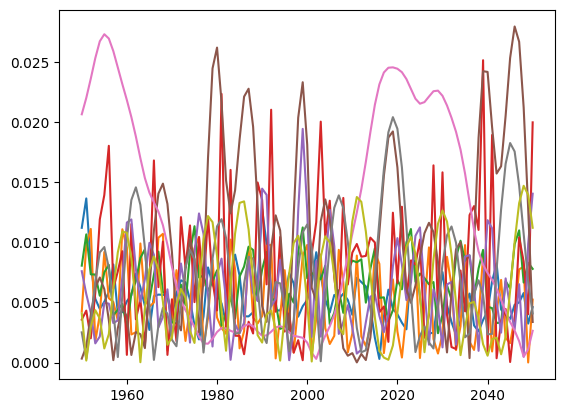

In [ ]:
for i in range(9):
    plt.plot(np.arange(1950,2051),np.stack(res)[:,i,0])
plt.show()

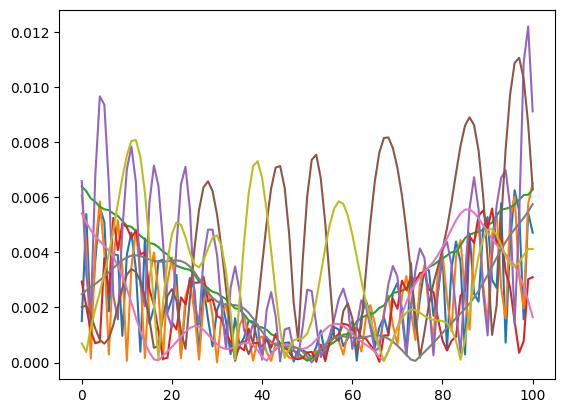

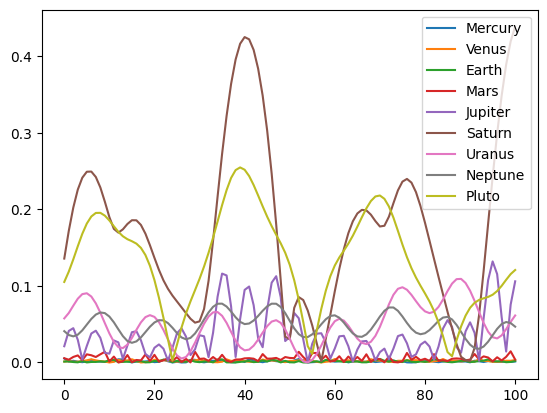

In [ ]:
for i in range(9):
    plt.plot(np.stack(res)[:,i,1])
plt.show()
for i in range(9):
    plt.plot(np.stack(res)[:,i,2],label=PLANETS[i])
plt.legend()
plt.show()

In [ ]:
df.head()

,Planet,SS Longitude,SF Longitude,Longitude Error (deg),SS Latitude,SF Latitude,Latitude Error (deg),SS Distance (AU),SF Distance (AU),Distance Error (AU),Distance Error (%)
0,Mercury,126.6792,126.6746,0.004619,6.8652,6.8605,0.004720,0.326835,0.326831,0.000004,0.001322
1,Venus,282.0315,282.0263,0.005239,-1.4684,-1.4618,0.006523,0.727571,0.727594,0.000023,0.003209
2,Earth,100.5612,100.5534,0.007794,0.0000,-0.0063,0.006286,0.983328,0.983347,0.000019,0.001894
3,Mars,198.3184,198.2984,0.019966,0.9507,0.9538,0.003100,1.623056,1.623118,0.000062,0.003803
4,Jupiter,117.1665,117.1805,0.014040,0.3813,0.3721,0.009130,5.247083,5.241526,0.005557,0.105962


In [ ]:
# ------------------------------------------------------------
# COMPARISON - FROM 50 YEARS BEFORE 2000 UP TO 50 YEARS AFTER -
# ****************** PRECESSION=FALSE ************************-
# ------------------------------------------------------------

# d = datetime.datetime()
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)

res=[]

for YEAR in tqdm(range(1950,2051)):

    # ------------------------------------------------------------
    # SOLARSYSTEM POSITIONS
    # ------------------------------------------------------------

    H = solarsystem.Heliocentric(
    year=YEAR,
    month=MONTH,
    day=DAY,
    hour=HOUR,
    minute=MINUTE,
    precession=False
)

    ss_positions = H.planets()

    # ------------------------------------------------------------
    # Time for skyfield
    # ------------------------------------------------------------

    ts = load.timescale()
    t = ts.utc(YEAR, MONTH, DAY, HOUR, MINUTE)

    results = []

    for planet in PLANETS:

        # -------------------------
        # solarsystem values
        # -------------------------

        ss_lon = ss_positions[planet][0]
        ss_lat = ss_positions[planet][1]
        ss_r   = ss_positions[planet][2]


        # -------------------------
        # skyfield values
        # -------------------------

        astrometric = sun.at(t).observe(planet_map[planet])

        lat, lon, distance = astrometric.ecliptic_latlon()

        sf_lon = lon.degrees % 360
        sf_lat = lat.degrees
        sf_r   = distance.au

        # -------------------------
        # errors
        # -------------------------

        # lon_error = ss_lon - sf_lon
        lon_error = abs(ss_lon - sf_lon)

        # handle wrap-around
        if lon_error > 180:
            lon_error = 360 - lon_error


        lat_error = abs(ss_lat - sf_lat)

        dist_error = abs(ss_r - sf_r)

        results.append({
            "Planet": planet,
            "SS Longitude": round(ss_lon, 4),
            "SF Longitude": round(sf_lon, 4),
            "Longitude Error (deg)": round(lon_error, 6),

            "SS Latitude": round(ss_lat, 4),
            "SF Latitude": round(sf_lat, 4),
            "Latitude Error (deg)": round(lat_error, 6),

            "SS Distance (AU)": round(ss_r, 6),
            "SF Distance (AU)": round(sf_r, 6),
            "Distance Error (AU)": round(dist_error, 8),
            "Distance Error (%)": round(100*dist_error/(0.5*ss_r+0.5*sf_r), 8)
        })
    df = pd.DataFrame(results)

    res.append(df[['Longitude Error (deg)', 'Latitude Error (deg)', 'Distance Error (%)']].values)

100%|██████████| 101/101 [00:01<00:00, 91.98it/s]


In [ ]:
np.stack(res).shape,np.stack(res).mean((0,1)),np.abs(np.stack(res)).mean((0,1))

((101, 9, 3),
 array([0.35424619, 0.00269976, 0.05035441]),
 array([0.35424619, 0.00269976, 0.05035441]))

In [ ]:
demical2arcs(np.abs(np.stack(res)).mean((0,1))[0]),demical2arcs(np.abs(np.stack(res)).mean((0,1))[1])

("0° 21.25'", "0° 0.16'")

In [ ]:
print('PLANET  \t','LONG DIFF \t', 'LAT DIFF \t', 'DISTANCE DIFF')
absres=np.round(np.abs(np.stack(res)).mean((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', absres[en,0], '\t', absres[en,1], '\t', absres[en,2])


PLANET  	 LONG DIFF 	 LAT DIFF 	 DISTANCE DIFF
Mercury    	 0.352161 	 0.002181 	 0.00153
Venus    	 0.352071 	 0.002099 	 0.001981
Earth    	 0.352859 	 0.003175 	 0.001456
Mars    	 0.353453 	 0.001978 	 0.005313
Jupiter    	 0.352829 	 0.003369 	 0.037482
Saturn    	 0.35207 	 0.004067 	 0.174956
Uranus    	 0.36392 	 0.002058 	 0.050161
Neptune    	 0.356398 	 0.002133 	 0.048898
Pluto    	 0.352455 	 0.003238 	 0.131413


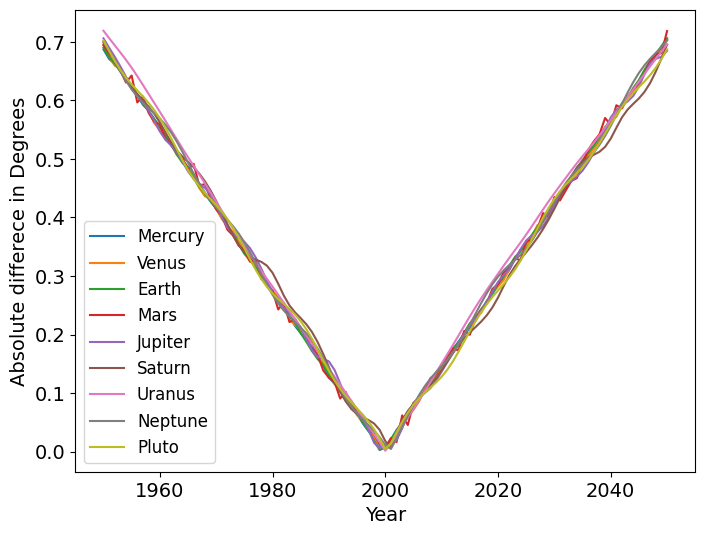

In [ ]:
plt.figure(figsize=(8,6))
for i in range(9):
    plt.plot(np.arange(1950,2051),np.stack(res)[:,i,0],label=PLANETS[i])
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Absolute differece in Degrees', fontsize=14)
plt.legend(fontsize=12)
plt.savefig('planet_logitude_precession_deviation_abs.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ------------------------------------------------------------
# COMPARISON - FROM 50 YEARS BEFORE 2000 UP TO 50 YEARS AFTER -
# ****************** PRECESSION=FALSE ************************-
# longitude --> Mean Error (not mean absolute error)
# ------------------------------------------------------------

# d = datetime.datetime()
d=datetime(YEAR, MONTH, DAY, HOUR, MINUTE, 0)

res=[]

for YEAR in tqdm(range(1950,2051)):

    # ------------------------------------------------------------
    # SOLARSYSTEM POSITIONS
    # ------------------------------------------------------------

    H = solarsystem.Heliocentric(
    year=YEAR,
    month=MONTH,
    day=DAY,
    hour=HOUR,
    minute=MINUTE,
    precession=False
)

    ss_positions = H.planets()

    # ------------------------------------------------------------
    # Time for skyfield
    # ------------------------------------------------------------

    ts = load.timescale()
    t = ts.utc(YEAR, MONTH, DAY, HOUR, MINUTE)

    results = []

    for planet in PLANETS:

        # -------------------------
        # solarsystem values
        # -------------------------

        ss_lon = ss_positions[planet][0]
        ss_lat = ss_positions[planet][1]
        ss_r   = ss_positions[planet][2]


        # -------------------------
        # skyfield values
        # -------------------------

        astrometric = sun.at(t).observe(planet_map[planet])

        lat, lon, distance = astrometric.ecliptic_latlon()

        sf_lon = lon.degrees % 360
        sf_lat = lat.degrees
        sf_r   = distance.au

        # -------------------------
        # errors
        # -------------------------

        lon_error = ss_lon - sf_lon
        # lon_error = abs(ss_lon - sf_lon)

        # handle wrap-around
        if lon_error > 180:
            lon_error = lon_error - 360
        if lon_error < -180:
            lon_error = 360 + lon_error


        lat_error = abs(ss_lat - sf_lat)

        dist_error = abs(ss_r - sf_r)

        results.append({
            "Planet": planet,
            "SS Longitude": round(ss_lon, 4),
            "SF Longitude": round(sf_lon, 4),
            "Longitude Error (deg)": round(lon_error, 6),

            "SS Latitude": round(ss_lat, 4),
            "SF Latitude": round(sf_lat, 4),
            "Latitude Error (deg)": round(lat_error, 6),

            "SS Distance (AU)": round(ss_r, 6),
            "SF Distance (AU)": round(sf_r, 6),
            "Distance Error (AU)": round(dist_error, 8),
            "Distance Error (%)": round(100*dist_error/(0.5*ss_r+0.5*sf_r), 8)
        })
    df = pd.DataFrame(results)

    res.append(df[['Longitude Error (deg)', 'Latitude Error (deg)', 'Distance Error (%)']].values)

100%|██████████| 101/101 [00:01<00:00, 93.12it/s]


In [ ]:
np.stack(res).shape,np.stack(res).mean((0,1)),np.abs(np.stack(res)).mean((0,1))

((101, 9, 3),
 array([0.00227963, 0.00269976, 0.05035441]),
 array([0.35424619, 0.00269976, 0.05035441]))

In [ ]:
demical2arcs(np.abs(np.stack(res)).mean((0,1))[0]),demical2arcs(np.abs(np.stack(res)).mean((0,1))[1])

("0° 21.25'", "0° 0.16'")

In [ ]:
print('PLANET  \t','LONG DIFF \t', 'LAT DIFF \t', 'DISTANCE DIFF')
absres=np.round(np.abs(np.stack(res)).mean((0)),6)
for en, p in enumerate(PLANETS):
    print(p, '   \t', absres[en,0], '\t', absres[en,1], '\t', absres[en,2])


PLANET  	 LONG DIFF 	 LAT DIFF 	 DISTANCE DIFF
Mercury    	 0.352161 	 0.002181 	 0.00153
Venus    	 0.352071 	 0.002099 	 0.001981
Earth    	 0.352859 	 0.003175 	 0.001456
Mars    	 0.353453 	 0.001978 	 0.005313
Jupiter    	 0.352829 	 0.003369 	 0.037482
Saturn    	 0.35207 	 0.004067 	 0.174956
Uranus    	 0.36392 	 0.002058 	 0.050161
Neptune    	 0.356398 	 0.002133 	 0.048898
Pluto    	 0.352455 	 0.003238 	 0.131413


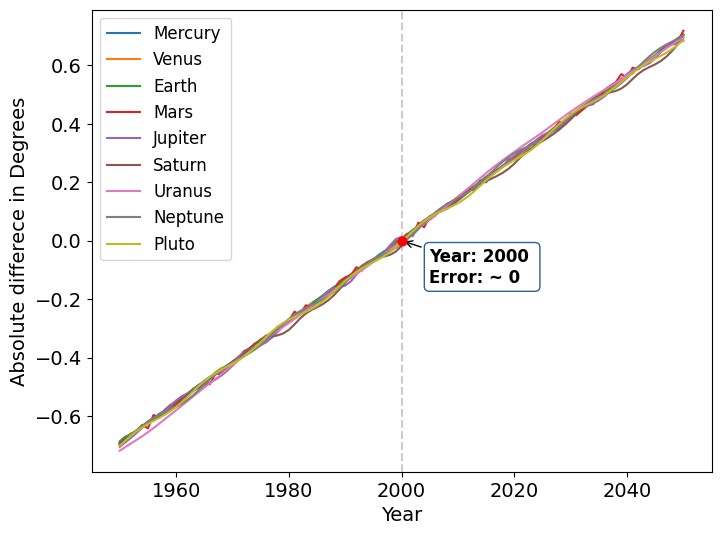

In [ ]:
plt.figure(figsize=(8,6))
for i in range(9):
    plt.plot(np.arange(1950,2051),np.stack(res)[:,i,0],label=PLANETS[i])
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Absolute differece in Degrees', fontsize=14)
plt.legend(fontsize=12)

# 3. Precision Annotation (Fixed Positioning)
# xytext=(10, 10) means 10 points right and 10 points up from the dot
plt.annotate('Year: 2000 \nError: ~ 0',
                xy=(2000, 0),
                xytext=(20, -30),
                textcoords='offset points',
                fontsize=12, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1a508b", alpha=0.9))

# 4. Vertical line to anchor the peak to the X-axis
plt.axvline(x=2000, color='gray', linestyle='--', alpha=0.4, zorder=1)
plt.scatter(2000, 0, color='red', s=40, zorder=5)


plt.savefig('planet_logitude_precession_deviation.png', dpi=300, bbox_inches='tight')
plt.show()

### SPEED TEST

In [ ]:
# ------------------------------------------------------------
# SolarSystem library speed - ONCE PER DAY (at 12 noon) FOR A SINGLE YEAR
# ------------------------------------------------------------

import time
# d = datetime.datetime()
d=datetime(1950, MONTH, DAY, HOUR, MINUTE, 0)

res=[]
start_time=time.time()
for nd in (range(36525)):
    f = d + timedelta(days=nd)

    H = solarsystem.Heliocentric(
    year=f.year,
    month=f.month,
    day=f.day,
    hour=HOUR,
    minute=MINUTE
)

    ss_positions = H.planets()
end_time=time.time()
print("Solarsystem's 100 full year (100*365.25 times) planet positions calculatations in",end_time-start_time)
print('Average planet position calculation for a single time', (end_time-start_time)/36525)
# ss_positions


Solarsystem's 100 full year (100*365.25 times) planet positions calculatations in 1.4288835525512695
Average planet position calculation for a single time 3.9120699590726067e-05
